In [30]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key="549d8602d24a67c414ae95371fbcc4e8")

cpi = fred.get_series("CPIAUCSL")
core_cpi = fred.get_series("CPILFESL")
pce = fred.get_series("PCEPI")
core_pce = fred.get_series("PCEPILFE")

main_df = pd.concat(
    [cpi, core_cpi, pce, core_pce],
    axis=1
)

main_df.columns = ["CPI", "Core_CPI", "PCE", "Core_PCE"]

main_df = main_df.loc["2019-01-01":]
print(main_df.head())

                CPI  Core_CPI      PCE  Core_PCE
2019-01-01  252.561   260.766  102.648   102.870
2019-02-01  253.319   261.186  102.836   102.963
2019-03-01  254.277   261.567  103.069   103.058
2019-04-01  255.233   261.997  103.360   103.265
2019-05-01  255.296   262.217  103.435   103.371


In [59]:
import numpy as np

file_path = "FSBI_data.csv"

df = pd.read_csv(file_path)

print(df.shape)
print(df.head())

print(df.info())
print(df.columns)
print(df.describe(include="all"))

(166407, 16)
     Period                                  Geo Sector Name Sub-Sector Name  \
0  20190101  Atlanta-Sandy Springs-Alpharetta GA         ALL             ALL   
1  20190101        Boston-Cambridge-Newton MA-NH         ALL             ALL   
2  20190101    Chicago-Naperville-Elgin IL-IN-WI         ALL             ALL   
3  20190101       Dallas-Fort Worth-Arlington TX         ALL             ALL   
4  20190101    Los Angeles-Long Beach-Anaheim CA         ALL             ALL   

   Real Sales Index - SA  Transactional Index - SA  Real Sales MOM % - SA  \
0                  98.00                     98.22                    0.0   
1                  99.58                     97.98                    0.0   
2                  97.15                     98.66                    0.0   
3                  97.82                     98.17                    0.0   
4                  96.54                     97.98                    0.0   

   Real Sales YOY % - SA  Transaction MOM %

In [4]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_report[(missing_report["missing_count"] != 0) |
               (missing_report["missing_percent"] != 0)]

,missing_count,missing_percent
Real Sales YOY % - NSA,2820,1.694640
Transaction YOY % - NSA,2820,1.694640
Real Sales YOY % - SA,2815,1.691636
Transaction YOY % - SA,2812,1.689833
Real Sales MOM % - NSA,1708,1.026399
Transaction MOM % - NSA,1708,1.026399
Real Sales MOM % - SA,1703,1.023394
Transaction MOM % - SA,1702,1.022794


In [6]:
for col in df.columns:
    if df[col].dtype == "object":
        print("\n", col)
        print(df[col].nunique())
        print(df[col].value_counts().head(10))


 Geo
61
Geo
CA    3560
TX    3558
FL    3554
US    3550
GA    3540
OH    3538
PA    3537
NY    3536
KS    3531
MO    3531
Name: count, dtype: int64

 Sector Name
14
Sector Name
Retail Trade                                                                                                                                           44681
Other Services (except Public Administration)                                                                                                          17291
Accommodation and Food Services                                                                                                                        13493
Wholesale Trade (Motor Vehicle and Motor Vehicle Parts, Metal and Mineral, Household Appliances and Electrical and Electronic Goods, Durable Goods)    12270
Transportation and Warehousing                                                                                                                          9881
Health Care and Social Assistance    

In [60]:
#OPTION 2: DROP ENTIRELY
cols_to_drop = [
    "Real Sales YOY % - NSA",
    "Transaction YOY % - NSA",
    "Real Sales YOY % - SA",
    "Transaction YOY %  - SA",
    "Real Sales MOM % - NSA",
    "Transaction MOM % - NSA",
    "Real Sales MOM % - SA",
    "Transaction MOM % - SA"
]

df = df[~(df[cols_to_drop] == 0).any(axis=1)]

In [33]:
df.head()

,Period,Geo,Sector Name,Sub-Sector Name,Real Sales Index - SA,Transactional Index - SA,Real Sales MOM % - SA,Real Sales YOY % - SA,Transaction MOM % - SA,Transaction YOY % - SA,Real Sales Index - NSA,Transactional Index - NSA,Real Sales MOM % - NSA,Real Sales YOY % - NSA,Transaction MOM % - NSA,Transaction YOY % - NSA
22918,20200101,Atlanta-Sandy Springs-Alpharetta GA,ALL,ALL,103.95,105.78,1.21,6.06,2.40,7.69,99.20,99.14,-1.29,6.17,-0.49,7.64
22919,20200101,Boston-Cambridge-Newton MA-NH,ALL,ALL,102.97,104.72,0.63,3.40,1.25,6.89,92.39,94.13,-8.73,4.30,-6.29,7.69
22920,20200101,Chicago-Naperville-Elgin IL-IN-WI,ALL,ALL,102.66,104.85,0.78,5.68,0.75,6.27,92.27,92.05,-5.43,5.92,-6.47,7.62
22921,20200101,Dallas-Fort Worth-Arlington TX,ALL,ALL,103.73,105.71,0.77,6.04,1.05,7.68,99.24,99.82,-1.47,5.60,-2.02,8.18
22922,20200101,Los Angeles-Long Beach-Anaheim CA,ALL,ALL,104.03,107.00,1.49,7.76,2.38,9.21,99.85,101.03,-1.05,7.70,0.23,9.24


In [9]:
import requests
import json

series = [
    "CUUR0000SA0", #All US Cities
    "CUUR0100SA0", #Northeast
    "CUUR0200SA0", #Midwest
    "CUUR0300SA0", #South
    "CUUR0400SA0", #West
    "CUURS12ASA0", #NY/Newark/Jersey
    "CUURS49ASA0", #LA/LongBeach/Anaheim
    "CUURS23ASA0", #Chicago/Naperville/Elgin
    "CUURS11ASA0", #Boston/Cambridge/Newton
    "CUURS37ASA0", #Philadelphia/Camden/Wilmington
    "CUURS35ASA0", #Washington/Arlington/Alexandria
    "CUURS49BSA0", #Atlanta/SandySprings/Roswell
    "CUURS35BSA0", #Miami/FtLauderdale/WestPalmBeach
    "CUURS37BSA0", #Dallas/FortWorth/Arlington
    #"CUURS37ASAO", #Houston/Woodlands/SugarLand
    "CUURS48ASA0", #Phoenix/Mesa/Scottsdale
    "CUURS48BSA0", #Denver/Aurora/Lakewood
    "CUURS49CSA0", #Seattle/Tacoma/Bellevue
    "CUURS49FSA0", #SF/Oakland/Hayward
    "CUURS49DSA0", #San Diego/Carlsbad
    "CUURS49ESA0", #Riverside San Bernardino
    "CUURS24ASA0", #Detroit/Warren/Dearborn
    "CUURS24BSA0", #Minneapolis/StPaul/Bloomington
    #"CUURS24CSA0", #StLouis, MO-IL
    "CUURS35CSA0" #Baltimore/Columbia/Towson
]

#BLS API imports
payload = {
    "seriesid": series,
    "startyear": "2019",
    "endyear": "2026"
}

r = requests.post(
    "https://api.bls.gov/publicAPI/v2/timeseries/data/",
    json=payload
)

bls_CPI = r.json()

rows = []
for series in bls_CPI["Results"]["series"]:
    series_id = series["seriesID"]
    for obs in series["data"]:
        rows.append({
            "series_id": series_id,
            "year": int(obs["year"]),
            "period": obs["period"],
            "month": obs["periodName"],
            "value": pd.to_numeric(obs["value"], errors="coerce")
        })
bls_CPI = pd.DataFrame(rows)
bls_CPI = bls_CPI[bls_CPI["period"].str.startswith("M")]

bls_CPI["date"] = pd.to_datetime(bls_CPI["year"].astype(str) + "-" + bls_CPI["period"].str[1:] + "-01")
bls_CPI = bls_CPI.sort_values(["series_id", "date"])

id_map = {
    "CUUR0000SA0": "All US Cities",
    "CUUR0100SA0": "Northeast",
    "CUUR0200SA0": "Midwest",
    "CUUR0300SA0": "South",
    "CUUR0400SA0": "West",

    "CUURS12ASA0": "NY/Newark/Jersey",
    "CUURS49ASA0": "LA/LongBeach/Anaheim",
    "CUURS23ASA0": "Chicago/Naperville/Elgin",
    "CUURS11ASA0": "Boston/Cambridge/Newton",
    "CUURS37ASA0": "Philadelphia/Camden/Wilmington",
    "CUURS35ASA0": "Washington/Arlington/Alexandria",
    "CUURS49BSA0": "Atlanta/SandySprings/Roswell",
    "CUURS35BSA0": "Miami/FtLauderdale/WestPalmBeach",
    "CUURS37BSA0": "Dallas/FortWorth/Arlington",

    "CUURS48ASA0": "Phoenix/Mesa/Scottsdale",
    "CUURS48BSA0": "Denver/Aurora/Lakewood",
    "CUURS49CSA0": "Seattle/Tacoma/Bellevue",
    "CUURS49FSA0": "SF/Oakland/Hayward",
    "CUURS49DSA0": "San Diego/Carlsbad",
    "CUURS49ESA0": "Riverside San Bernardino",
    "CUURS24ASA0": "Detroit/Warren/Dearborn",
    "CUURS24BSA0": "Minneapolis/StPaul/Bloomington",
    "CUURS35CSA0": "Baltimore/Columbia/Towson"
}
bls_CPI["region"] = bls_CPI["series_id"].map(id_map)
print(bls_CPI.head())

      series_id  year period     month    value       date         region
88  CUUR0000SA0  2019    M01   January  251.712 2019-01-01  All US Cities
87  CUUR0000SA0  2019    M02  February  252.776 2019-02-01  All US Cities
86  CUUR0000SA0  2019    M03     March  254.202 2019-03-01  All US Cities
85  CUUR0000SA0  2019    M04     April  255.548 2019-04-01  All US Cities
84  CUUR0000SA0  2019    M05       May  256.092 2019-05-01  All US Cities


In [70]:
#BLS macros
series = [
    "LNS14000000",  # unemployment rate
    "LNS11300000",  # labor force participation
    "CES0000000001", # payroll employment
    "CES0500000003", # hourly earnings
    #"CIU2010000000000I", #total compensation
    "WPSFD4", #final demand PPI
    "WPSFD4A03", #energy PPI
    "WPSFD4A01", #food PPI
    "WPSID61", #intermediate demand
    "WPSID62", #crude goods
    "CUUR0000SEHA",  # rent
    "CUUR0000SEHC",  # OER
    "CUUR0000SETB01", # gasoline
    "CUUR0000SEHF02",  # electricity
    "CUUR0000SEHF01", #fuel oil
    "EIUIR", #import price index
    "EIEIR" #export price index
]

payload = {
    "seriesid": series,
    "startyear": "2019",
    "endyear": "2026"
}

r = requests.post(
    "https://api.bls.gov/publicAPI/v2/timeseries/data/",
    json=payload
)

data = r.json()
records = []
for s in data["Results"]["series"]:
    sid = s["seriesID"]

    for item in s["data"]:
        records.append({
            "series": sid,
            "year": item["year"],
            "period": item["period"],
            "value": item["value"]
        })
bls_macros = pd.DataFrame(records)
bls_macros["date"] = pd.to_datetime(bls_macros["year"] + bls_macros["period"].str[1:] + "01", format="%Y%m%d")

series_map = {
    "LNS14000000": "unemployment_rate",
    "LNS11300000": "labor_force_participation",
    "CES0000000001": "payroll_employment",
    "CES0500000003": "avg_hourly_earnings",

    "WPSFD4": "ppi_final_demand",
    "WPSFD4A03": "ppi_energy",
    "WPSFD4A01": "ppi_food",
    "WPSID61": "ppi_intermediate",
    "WPSID62": "ppi_crude",

    "CUUR0000SEHA": "cpi_rent",
    "CUUR0000SEHC": "cpi_oer",
    "CUUR0000SETB01": "cpi_gasoline",
    "CUUR0000SEHF02": "cpi_electricity",
    "CUUR0000SEHF01": "cpi_fuel_oil",

    "EIUIR": "import_price_index",
    "EIEIR": "export_price_index"
}
bls_macros["macro"] = bls_macros["series"].map(series_map)
bls_macros = bls_macros.pivot_table(
    index=["date"],
    columns="macro",
    values="value",
    aggfunc="first"
)
bls_macros.head()

macro,avg_hourly_earnings,cpi_electricity,cpi_fuel_oil,cpi_gasoline,cpi_oer,cpi_rent,import_price_index,labor_force_participation,payroll_employment,ppi_crude,ppi_final_demand,ppi_intermediate,unemployment_rate
date,,,,,,,,,,,,,
2019-01-01,27.59,180.106,210.920,201.194,320.789,325.597,124.6,63.1,150060,192.9,117.0,198.6,4.0
2019-02-01,27.69,174.950,210.939,206.749,321.627,326.351,125.9,63.1,150067,188.1,117.2,199.1,3.8
2019-03-01,27.77,174.089,210.937,225.282,322.482,327.513,126.6,63.0,150295,188.2,117.6,200.1,3.8
2019-04-01,27.79,171.004,210.525,248.499,323.426,328.678,126.8,62.8,150591,191.0,118.2,200.7,3.7
2019-05-01,27.88,168.826,212.326,254.551,324.143,329.333,127.0,62.9,150618,186.4,118.3,199.6,3.6


In [71]:
bls_macros.shape

(90, 13)

In [11]:
#BEA PCE
api_key = "50BD1804-7652-4343-88D6-B7B298A1C0D2"
url = (
    "https://apps.bea.gov/api/data"
    f"?UserID={api_key}"
    "&method=GetData"
    "&datasetname=NIPA"
    "&TableName=T20305"
    "&Frequency=Q"
    "&Year=ALL"
    "&ResultFormat=JSON"
)
r = requests.get(url)
data = r.json()
bea_pce = pd.DataFrame(data["BEAAPI"]["Results"]["Data"])
bea_pce["DataValue"] = pd.to_numeric(
    bea_pce["DataValue"].str.replace(",", ""),
    errors="coerce"
)
#print(bea_pce.head())
#print(bea_pce.groupby("TimePeriod").size().head(10))
#print(bea_pce["SeriesCode"].value_counts())
#print(bea_pce["LineDescription"].value_counts())
bea_pce["date"] = pd.to_datetime(bea_pce["TimePeriod"])
bea_pce = bea_pce[["date", "SeriesCode", "LineDescription", "DataValue"]]
bea_pce = bea_pce.rename(columns={"DataValue": "PCE"})
bea_pce = bea_pce.set_index("date")
print(bea_pce.head())

           SeriesCode                          LineDescription     PCE
date                                                                  
1947-01-01     DPCERC  Personal consumption expenditures (PCE)  156161
1947-04-01     DPCERC  Personal consumption expenditures (PCE)  160031
1947-07-01     DPCERC  Personal consumption expenditures (PCE)  163543
1947-10-01     DPCERC  Personal consumption expenditures (PCE)  167672
1948-01-01     DPCERC  Personal consumption expenditures (PCE)  170372


C:\Users\ericq\AppData\Local\Temp\ipykernel_8744\3470344479.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bea_pce["date"] = pd.to_datetime(bea_pce["TimePeriod"])


In [12]:
codebook = (
    bea_pce[["SeriesCode", "LineDescription"]]
    .drop_duplicates()
    .sort_values(["SeriesCode", "LineDescription"])
)

codebook

,SeriesCode,LineDescription
date,,
1947-01-01,DCLORC,Clothing and footwear
1947-01-01,DDURRC,Durable goods
1947-01-01,DFDHRC,Furnishings and durable household equipment
1959-01-01,DFSARC,Food services and accommodations
1947-01-01,DFXARC,Food and beverages purchased for off-premises ...
1947-01-01,DGDSRC,Goods
1947-01-01,DGOERC,Gasoline and other energy goods
1959-01-01,DHCERC,Household consumption expenditures (for services)
1959-01-01,DHLCRC,Health care


In [13]:
#BEA income macros
api_key = "50BD1804-7652-4343-88D6-B7B298A1C0D2"

url = (
    "https://apps.bea.gov/api/data"
    "?UserID=" + api_key +
    "&method=GetData"
    "&datasetname=NIPA"
    "&TableName=T20100"
    "&Frequency=Q"
    "&Year=ALL"
    "&ResultFormat=JSON"
)

r = requests.get(url)
#print(r.status_code)
#print(json.dumps(r.json(), indent=2)[:2000])  # First 2000 characters

bea_json = r.json()
bea_income = pd.DataFrame(bea_json["BEAAPI"]["Results"]["Data"])
bea_income["DataValue"] = pd.to_numeric(bea_income["DataValue"].str.replace(",",""),
                                        errors="coerce")
bea_income["date"] = pd.to_datetime(bea_income["TimePeriod"])

PI   = bea_income[bea_income["LineNumber"] == "1"]
COMP = bea_income[bea_income["LineNumber"] == "2"]
DPI  = bea_income[bea_income["LineNumber"] == "27"]
SAVE = bea_income[bea_income["LineNumber"] == "29"]
PI = PI.set_index("date")[["DataValue"]].rename(columns={"DataValue": "Personal_Income"})
COMP = COMP.set_index("date")[["DataValue"]].rename(columns={"DataValue": "Compensation"})
DPI = DPI.set_index("date")[["DataValue"]].rename(columns={"DataValue": "DPI"})
SAVE = SAVE.set_index("date")[["DataValue"]].rename(columns={"DataValue": "Saving_Rate"})
macro_income = PI.join([COMP, DPI, SAVE], how="outer").sort_index()
#macro_income = PI[["date", "DataValue"]].rename(columns={"DataValue": "Personal_Income"})
#macro_income["Compensation"] = COMP.set_index("date")["DataValue"]
#macro_income["DPI"] = DPI.set_index("date")["DataValue"]
#macro_income["Saving_Rate"] = SAVE.set_index("date")["DataValue"]
bea_income = macro_income.sort_values("date")
print(bea_income.head())

            Personal_Income  Compensation       DPI  Saving_Rate
date                                                            
1947-01-01         189713.0      128989.0  170548.0     156161.0
1947-04-01         189720.0      130787.0  170245.0     160031.0
1947-07-01         197768.0      132781.0  178047.0     163543.0
1947-10-01         200715.0      136877.0  179916.0     167672.0
1948-01-01         206493.0      140405.0  185295.0     170372.0


C:\Users\ericq\AppData\Local\Temp\ipykernel_8744\3832378049.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bea_income["date"] = pd.to_datetime(bea_income["TimePeriod"])


In [14]:
#BEA GDP macros
url = (
    "https://apps.bea.gov/api/data"
    f"?UserID={api_key}"
    "&method=GetData"
    "&datasetname=NIPA"
    "&TableName=T10105"
    "&Frequency=Q"
    "&Year=ALL"
    "&ResultFormat=JSON"
)

r = requests.get(url)
gdp = pd.DataFrame(r.json()["BEAAPI"]["Results"]["Data"])

gdp["DataValue"] = pd.to_numeric(
    gdp["DataValue"].str.replace(",", ""),
    errors="coerce"
)

#print(gdp["SeriesCode"].value_counts())
#print(gdp["LineDescription"].value_counts())

gdp["date"] = pd.PeriodIndex(
    gdp["TimePeriod"],
    freq="Q"
).to_timestamp()
core_keys = [
    "Gross domestic product",
    "Personal consumption expenditures",
    "Gross private domestic investment",
    "Government consumption expenditures and gross investment",
    "Net exports and goods and services"
]

gdp_core = gdp[gdp["LineDescription"].isin(core_keys)]
bea_gdp = gdp_core.pivot_table(
    index="date",
    columns="LineDescription",
    values="DataValue"
).sort_index()
bea_gdp.head()

LineDescription,Government consumption expenditures and gross investment,Gross domestic product,Gross private domestic investment,Personal consumption expenditures
date,,,,
1947-01-01,40274.0,243164.0,35854.0,156161.0
1947-04-01,40138.0,245968.0,34505.0,160031.0
1947-07-01,39361.0,249585.0,34911.0,163543.0
1947-10-01,39534.0,259745.0,43250.0,167672.0
1948-01-01,40875.0,265742.0,47202.0,170372.0


In [26]:
#FRED macros
monthly_series = {
    "HOUST": "housing_starts",
    "PERMIT": "housing_permits",
    "PPIACO": "commodity_ppi",
    "M1SL": "m1",
    "M2SL": "m2",
    "MICH": "inflation_expectations_1y",
    "FRGSHPUSM649NCIS": "freight_index",
    "FEDFUNDS": "fed_funds"
}

daily_series = {
    "DGS2": "treasury_2y",
    "DGS10": "treasury_10y",
    "T5YIE": "breakeven_5y",
    "T10YIE": "breakeven_10y",
    "DTWEXBGS": "usd_index"
}

weekly_series = {
    "NFCI": "nfci",
    "STLFSI4": "stl_fsi"
}

fred_monthly = pd.DataFrame({
    name: fred.get_series(code)
    for code, name in monthly_series.items()
}).loc["2019-01-01":]

fred_daily = pd.DataFrame({
    name: fred.get_series(code)
    for code, name in daily_series.items()
}).loc["2019-01-01":]

fred_weekly = pd.DataFrame({
    name: fred.get_series(code)
    for code, name in weekly_series.items()
}).loc["2019-01-01":]

print("Monthly FRED data:")
print(fred_monthly.head())
print("\n")

print("Daily FRED data")
print(fred_daily.head())
print("\n")

print("Weekly/Irregular FRED data")
print(fred_weekly.head())

Monthly FRED data:
            housing_starts  housing_permits  commodity_ppi      m1       m2  \
2019-01-01          1226.0           1254.0          199.1  3787.8  14459.7   
2019-02-01          1121.0           1286.0          199.2  3785.5  14506.3   
2019-03-01          1191.0           1295.0          200.8  3782.3  14557.5   
2019-04-01          1272.0           1322.0          202.1  3827.7  14594.7   
2019-05-01          1293.0           1347.0          201.7  3824.4  14704.4   

            inflation_expectations_1y  freight_index  fed_funds  
2019-01-01                        2.7          1.128       2.40  
2019-02-01                        2.6          1.173       2.40  
2019-03-01                        2.5          1.197       2.41  
2019-04-01                        2.5          1.194       2.42  
2019-05-01                        2.9          1.228       2.39  


Daily FRED data
            treasury_2y  treasury_10y  breakeven_5y  breakeven_10y  usd_index
2019-01-01    

In [17]:
cutoff = pd.to_datetime("2019-01-01")

bea_gdp = bea_gdp.loc[bea_gdp.index >= cutoff]
bea_income = bea_income.loc[bea_income.index >= cutoff]
bea_pce = bea_pce.loc[bea_pce.index >= cutoff]

In [53]:
fred_monthly.index = pd.to_datetime(fred_monthly.index)
fred_daily.index = pd.to_datetime(fred_daily.index)
fred_weekly.index = pd.to_datetime(fred_weekly.index)

fred_monthly = fred_monthly.resample("MS").last()
fred_daily_monthly = fred_daily.resample("MS").last()
fred_weekly_monthly = fred_weekly.resample("MS").last()
fred_all = pd.concat(
    [
        fred_monthly,
        fred_daily_monthly,
        fred_weekly_monthly
    ],
    axis=1
)

In [54]:
fred_all.shape

(91, 15)

In [55]:
fred_all.head()

,housing_starts,housing_permits,commodity_ppi,m1,m2,inflation_expectations_1y,freight_index,fed_funds,treasury_2y,treasury_10y,breakeven_5y,breakeven_10y,usd_index,nfci,stl_fsi
2019-01-01,1226.0,1254.0,199.1,3787.8,14459.7,2.7,1.128,2.40,2.45,2.63,1.70,1.85,113.5504,-0.506,-0.1226
2019-02-01,1121.0,1286.0,199.2,3785.5,14506.3,2.6,1.173,2.40,2.52,2.73,1.84,1.95,114.1991,-0.581,-0.5210
2019-03-01,1191.0,1295.0,200.8,3782.3,14557.5,2.5,1.197,2.41,2.27,2.41,1.78,1.88,115.1371,-0.605,-0.3180
2019-04-01,1272.0,1322.0,202.1,3827.7,14594.7,2.5,1.194,2.42,2.27,2.51,1.85,1.95,115.3281,-0.614,-0.6323
2019-05-01,1293.0,1347.0,201.7,3824.4,14704.4,2.9,1.228,2.39,1.95,2.14,1.58,1.74,116.7273,-0.580,-0.1821


In [61]:
fsbi_df = df.copy()
fsbi_df["Period"] = (
    pd.to_datetime(fsbi_df["Period"].astype(str), format="%Y%m%d")
      .dt.to_period("M")
      .dt.to_timestamp(how="start")
)

In [62]:
fsbi_df.shape

(142028, 16)

In [63]:
fsbi_df.head()

,Period,Geo,Sector Name,Sub-Sector Name,Real Sales Index - SA,Transactional Index - SA,Real Sales MOM % - SA,Real Sales YOY % - SA,Transaction MOM % - SA,Transaction YOY % - SA,Real Sales Index - NSA,Transactional Index - NSA,Real Sales MOM % - NSA,Real Sales YOY % - NSA,Transaction MOM % - NSA,Transaction YOY % - NSA
22918,2020-01-01,Atlanta-Sandy Springs-Alpharetta GA,ALL,ALL,103.95,105.78,1.21,6.06,2.40,7.69,99.20,99.14,-1.29,6.17,-0.49,7.64
22919,2020-01-01,Boston-Cambridge-Newton MA-NH,ALL,ALL,102.97,104.72,0.63,3.40,1.25,6.89,92.39,94.13,-8.73,4.30,-6.29,7.69
22920,2020-01-01,Chicago-Naperville-Elgin IL-IN-WI,ALL,ALL,102.66,104.85,0.78,5.68,0.75,6.27,92.27,92.05,-5.43,5.92,-6.47,7.62
22921,2020-01-01,Dallas-Fort Worth-Arlington TX,ALL,ALL,103.73,105.71,0.77,6.04,1.05,7.68,99.24,99.82,-1.47,5.60,-2.02,8.18
22922,2020-01-01,Los Angeles-Long Beach-Anaheim CA,ALL,ALL,104.03,107.00,1.49,7.76,2.38,9.21,99.85,101.03,-1.05,7.70,0.23,9.24


In [64]:
bls_macros.shape

(90, 13)

In [65]:
bls_macros.head()

macro,avg_hourly_earnings,cpi_electricity,cpi_fuel_oil,cpi_gasoline,cpi_oer,cpi_rent,import_price_index,labor_force_participation,payroll_employment,ppi_crude,ppi_final_demand,ppi_intermediate,unemployment_rate
date,,,,,,,,,,,,,
2019-01-01,27.59,180.106,210.920,201.194,320.789,325.597,124.6,63.1,150060,192.9,117.0,198.6,4.0
2019-02-01,27.69,174.950,210.939,206.749,321.627,326.351,125.9,63.1,150067,188.1,117.2,199.1,3.8
2019-03-01,27.77,174.089,210.937,225.282,322.482,327.513,126.6,63.0,150295,188.2,117.6,200.1,3.8
2019-04-01,27.79,171.004,210.525,248.499,323.426,328.678,126.8,62.8,150591,191.0,118.2,200.7,3.7
2019-05-01,27.88,168.826,212.326,254.551,324.143,329.333,127.0,62.9,150618,186.4,118.3,199.6,3.6


In [72]:
macro = (
    fred_all
    .join(bls_macros, how="outer")
)

macro.index.name = "date"
macro.shape

(91, 28)

In [73]:
macro.head()

,housing_starts,housing_permits,commodity_ppi,m1,m2,inflation_expectations_1y,freight_index,fed_funds,treasury_2y,treasury_10y,...,cpi_gasoline,cpi_oer,cpi_rent,import_price_index,labor_force_participation,payroll_employment,ppi_crude,ppi_final_demand,ppi_intermediate,unemployment_rate
date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,1226.0,1254.0,199.1,3787.8,14459.7,2.7,1.128,2.40,2.45,2.63,...,201.194,320.789,325.597,124.6,63.1,150060,192.9,117.0,198.6,4.0
2019-02-01,1121.0,1286.0,199.2,3785.5,14506.3,2.6,1.173,2.40,2.52,2.73,...,206.749,321.627,326.351,125.9,63.1,150067,188.1,117.2,199.1,3.8
2019-03-01,1191.0,1295.0,200.8,3782.3,14557.5,2.5,1.197,2.41,2.27,2.41,...,225.282,322.482,327.513,126.6,63.0,150295,188.2,117.6,200.1,3.8
2019-04-01,1272.0,1322.0,202.1,3827.7,14594.7,2.5,1.194,2.42,2.27,2.51,...,248.499,323.426,328.678,126.8,62.8,150591,191.0,118.2,200.7,3.7
2019-05-01,1293.0,1347.0,201.7,3824.4,14704.4,2.9,1.228,2.39,1.95,2.14,...,254.551,324.143,329.333,127.0,62.9,150618,186.4,118.3,199.6,3.6


In [79]:
data = (
    fsbi_df
    .merge(
        macro,
        left_on="Period",
        right_index=True,
        how="left"
    )
    .merge(
        main_df,
        left_on="Period",
        right_index=True,
        how="left"
    )
)

In [80]:
data.shape

(142028, 48)

In [81]:
data.head()

,Period,Geo,Sector Name,Sub-Sector Name,Real Sales Index - SA,Transactional Index - SA,Real Sales MOM % - SA,Real Sales YOY % - SA,Transaction MOM % - SA,Transaction YOY % - SA,...,labor_force_participation,payroll_employment,ppi_crude,ppi_final_demand,ppi_intermediate,unemployment_rate,CPI,Core_CPI,PCE,Core_PCE
22918,2020-01-01,Atlanta-Sandy Springs-Alpharetta GA,ALL,ALL,103.95,105.78,1.21,6.06,2.40,7.69,...,63.3,152031,186.2,119.2,197.1,3.6,259.127,266.716,104.49,104.507
22919,2020-01-01,Boston-Cambridge-Newton MA-NH,ALL,ALL,102.97,104.72,0.63,3.40,1.25,6.89,...,63.3,152031,186.2,119.2,197.1,3.6,259.127,266.716,104.49,104.507
22920,2020-01-01,Chicago-Naperville-Elgin IL-IN-WI,ALL,ALL,102.66,104.85,0.78,5.68,0.75,6.27,...,63.3,152031,186.2,119.2,197.1,3.6,259.127,266.716,104.49,104.507
22921,2020-01-01,Dallas-Fort Worth-Arlington TX,ALL,ALL,103.73,105.71,0.77,6.04,1.05,7.68,...,63.3,152031,186.2,119.2,197.1,3.6,259.127,266.716,104.49,104.507
22922,2020-01-01,Los Angeles-Long Beach-Anaheim CA,ALL,ALL,104.03,107.00,1.49,7.76,2.38,9.21,...,63.3,152031,186.2,119.2,197.1,3.6,259.127,266.716,104.49,104.507


In [82]:
full_data = data.copy()

post_covid_data = data[data["Period"] >= "2022-01-01"].copy()

print(len(full_data))
print(len(post_covid_data))

numeric_cols = full_data.select_dtypes(include="number").columns

summary = pd.DataFrame({
    "Full Mean": full_data[numeric_cols].mean(),
    "Post-2022 Mean": post_covid_data[numeric_cols].mean(),
    "Full Std": full_data[numeric_cols].std(),
    "Post-2022 Std": post_covid_data[numeric_cols].std()
})

summary["Mean Difference"] = (
    summary["Post-2022 Mean"] - summary["Full Mean"]
)

summary.head()

142028
96887


,Full Mean,Post-2022 Mean,Full Std,Post-2022 Std,Mean Difference
Real Sales Index - SA,116.317628,119.760127,27.829394,29.479052,3.442499
Transactional Index - SA,117.296290,123.029289,38.542904,42.006932,5.732999
Real Sales MOM % - SA,0.435559,0.056630,7.834257,3.770867,-0.378929
Real Sales YOY % - SA,4.391871,1.426613,20.416852,12.556529,-2.965258
Transaction MOM % - SA,0.622022,0.373961,9.481169,4.385596,-0.248061


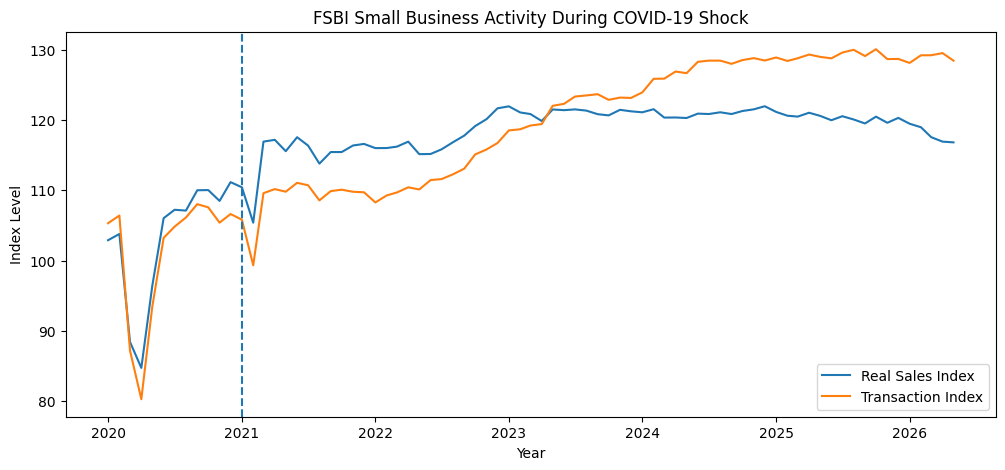

In [ ]:
import matplotlib as plt
fsbi_monthly = (
    fsbi_df
    .groupby("Period")
    [
        [
            "Real Sales Index - SA",
            "Transactional Index - SA"
        ]
    ]
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    fsbi_monthly.index,
    fsbi_monthly["Real Sales Index - SA"],
    label="Real Sales Index"
)

plt.plot(
    fsbi_monthly.index,
    fsbi_monthly["Transactional Index - SA"],
    label="Transaction Index"
)

plt.axvline(
    pd.Timestamp("2021-01-01"),
    linestyle="--"
)

plt.title("FSBI Small Business Activity During COVID-19 Shock")
plt.xlabel("Year")
plt.ylabel("Index Level")
plt.legend()
plt.savefig(
    "fsbi_covid_shock.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

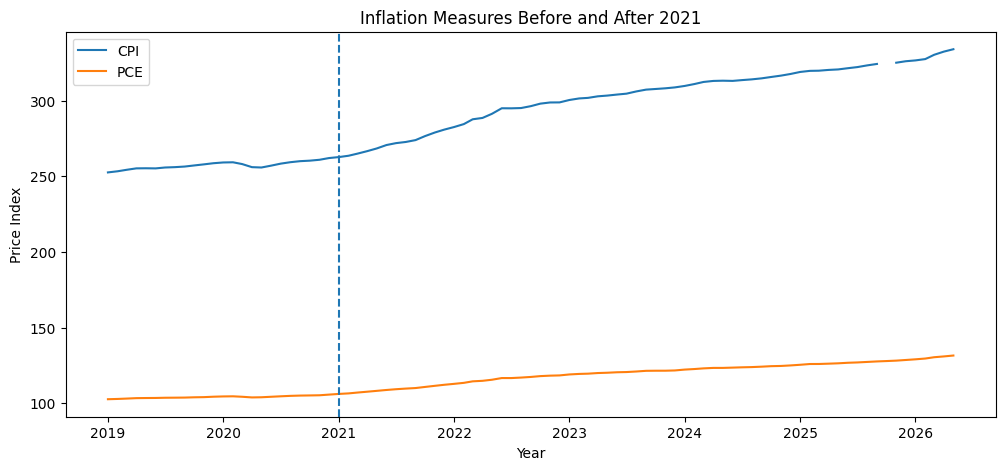

In [87]:
plt.figure(figsize=(12,5))

plt.plot(
    main_df.index,
    main_df["CPI"],
    label="CPI"
)

plt.plot(
    main_df.index,
    main_df["PCE"],
    label="PCE"
)

plt.axvline(
    pd.Timestamp("2021-01-01"),
    linestyle="--"
)

plt.title("Inflation Measures Before and After 2021")
plt.xlabel("Year")
plt.ylabel("Price Index")
plt.legend()
plt.show()

C:\Users\ericq\AppData\Local\Temp\ipykernel_8744\2686916383.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ].pct_change(12) * 100


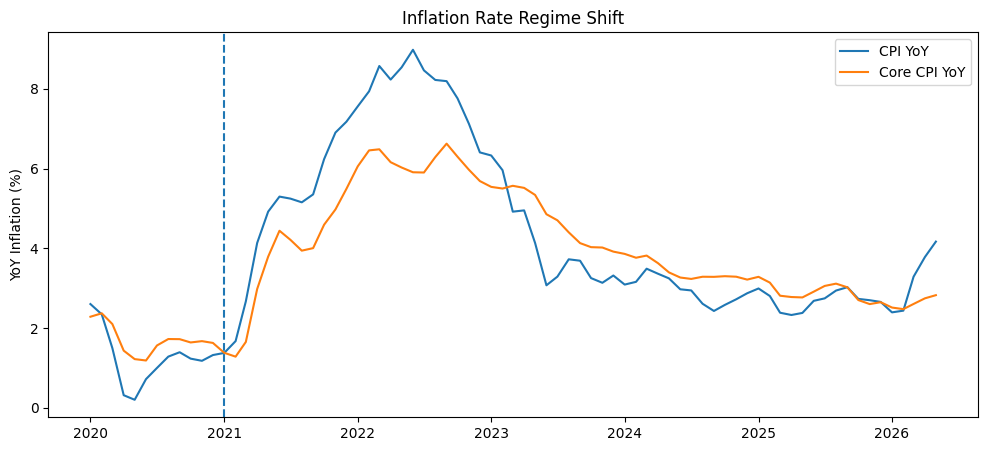

In [93]:
inflation_yoy = main_df[
    [
        "CPI",
        "Core_CPI",
        "PCE",
        "Core_PCE"
    ]
].pct_change(12) * 100


plt.figure(figsize=(12,5))

plt.plot(
    inflation_yoy.index,
    inflation_yoy["CPI"],
    label="CPI YoY"
)

plt.plot(
    inflation_yoy.index,
    inflation_yoy["Core_CPI"],
    label="Core CPI YoY"
)

plt.axvline(
    pd.Timestamp("2021-01-01"),
    linestyle="--"
)

plt.title("Inflation Rate Regime Shift")
plt.ylabel("YoY Inflation (%)")
plt.legend()

plt.savefig(
    "inflation_regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

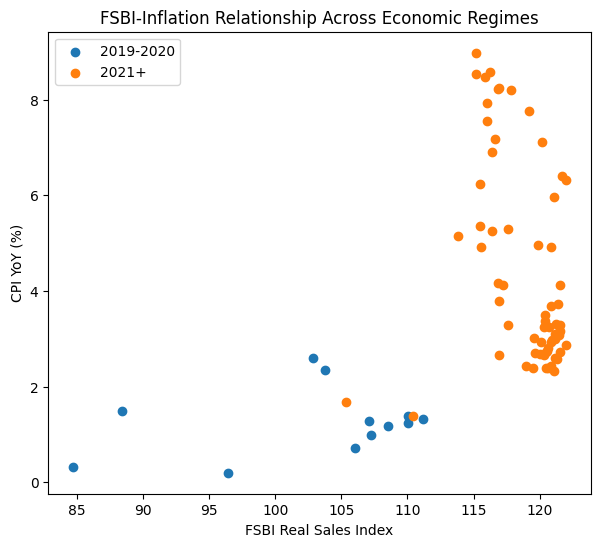

In [94]:
merged = (
    fsbi_monthly
    .join(inflation_yoy["CPI"])
    .dropna()
)

merged["period"] = (
    merged.index >= pd.Timestamp("2021-01-01")
)

plt.figure(figsize=(7,6))

plt.scatter(
    merged.loc[~merged["period"], "Real Sales Index - SA"],
    merged.loc[~merged["period"], "CPI"],
    label="2019-2020"
)

plt.scatter(
    merged.loc[merged["period"], "Real Sales Index - SA"],
    merged.loc[merged["period"], "CPI"],
    label="2021+"
)

plt.xlabel("FSBI Real Sales Index")
plt.ylabel("CPI YoY (%)")
plt.title("FSBI-Inflation Relationship Across Economic Regimes")
plt.legend()
plt.savefig(
    "fsbi_inflation_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
from scipy.stats import ttest_ind


pre = data.loc[
    data["Period"] < "2021-01-01",
    "Real Sales Index - SA"
].dropna()


post = data.loc[
    data["Period"] >= "2021-01-01",
    "Real Sales Index - SA"
].dropna()


stat, p = ttest_ind(
    pre,
    post,
    equal_var=False
)

print(stat, p)

-93.92935024519794 0.0


In [98]:
fsbi = fsbi_df[
    (fsbi_df["Geo"] == "US") &
    (fsbi_df["Sector Name"] == "ALL") &
    (fsbi_df["Sub-Sector Name"] == "ALL")
].copy()

fsbi_features = fsbi[
    [
        "Period",
        "Real Sales Index - SA",
        "Transactional Index - SA",
        "Real Sales YOY % - SA", 
        "Transaction YOY %  - SA"
    ]
].copy()

fsbi_vars = [
    "Real Sales Index - SA",
    "Transactional Index - SA",
    "Real Sales YOY % - SA", 
    "Transaction YOY %  - SA"
]


for col in fsbi_vars:
    for lag in [1,2,3]:
        fsbi_features[f"{col}_lag{lag}"] = (
            fsbi_features[col].shift(lag)
        )

fsbi_features = fsbi_features.drop(
    columns=fsbi_vars
)

In [100]:
macro["yield_spread_10y2y"] = (
    macro["treasury_10y"]
    -
    macro["treasury_2y"]
)

macro_vars = [
    "fed_funds",
    "treasury_10y",
    "yield_spread_10y2y",
    "breakeven_5y",
    "unemployment_rate",
    "avg_hourly_earnings",
    "ppi_final_demand",
    "cpi_rent",
    "cpi_oer",
    "inflation_expectations_1y",
    "usd_index"
]

macro_features = macro[macro_vars].copy()
macro_features = macro_features.shift(1)

In [101]:
targets = main_df[
    [
        "CPI",
        "Core_CPI",
        "PCE",
        "Core_PCE"
    ]
].copy()

model_data = (
    fsbi_features
    .merge(
        macro_features,
        left_on="Period",
        right_index=True,
        how="inner"
    )
    .merge(
        targets,
        left_on="Period",
        right_index=True,
        how="inner"
    )
)

In [102]:
model_data.shape

(76, 28)

In [114]:
model_data.head()

,Period,Real Sales Index - SA_lag1,Real Sales Index - SA_lag2,Real Sales Index - SA_lag3,Transactional Index - SA_lag1,Transactional Index - SA_lag2,Transactional Index - SA_lag3,Real Sales YOY % - SA_lag1,Real Sales YOY % - SA_lag2,Real Sales YOY % - SA_lag3,...,avg_hourly_earnings,ppi_final_demand,cpi_rent,cpi_oer,inflation_expectations_1y,usd_index,CPI,Core_CPI,PCE,Core_PCE
24545,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.38,119.0,336.789,330.527,2.3,114.6690,259.127,266.716,104.490,104.507
26446,2020-02-01,102.64,NaN,NaN,105.10,NaN,NaN,5.36,NaN,NaN,...,28.43,119.2,337.825,331.522,2.5,115.7345,259.250,267.370,104.573,104.711
28342,2020-03-01,103.18,102.64,NaN,105.76,105.10,NaN,7.75,5.36,NaN,...,28.54,118.6,338.616,332.177,2.4,117.6568,258.076,267.054,104.271,104.632
30188,2020-04-01,86.00,103.18,102.64,82.88,105.76,105.10,-11.53,7.75,5.36,...,28.73,118.0,339.519,332.864,2.2,122.5301,256.032,265.746,103.838,104.293
32045,2020-05-01,81.59,86.00,103.18,77.94,82.88,105.76,-15.79,-11.53,7.75,...,30.04,116.6,340.135,333.358,2.1,122.3270,255.802,265.412,103.942,104.402


In [115]:
eda_data = data.copy()
data = model_data.copy()

In [116]:
eda_summary = pd.DataFrame({
    "Observations": [len(data)],
    "Features": [data.shape[1]-5],  # excluding date + targets
    "Start Date": [data["Period"].min()],
    "End Date": [data["Period"].max()]
})

eda_summary

,Observations,Features,Start Date,End Date
0,76,23,2020-01-01,2026-05-01


In [117]:
missing_report = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_report[missing_report > 0]

Real Sales Index - SA_lag3       3
Transactional Index - SA_lag3    3
Real Sales YOY % - SA_lag3       3
Transaction YOY %  - SA_lag3     3
Real Sales Index - SA_lag2       2
Transactional Index - SA_lag2    2
Real Sales YOY % - SA_lag2       2
Transaction YOY %  - SA_lag2     2
Transaction YOY %  - SA_lag1     1
CPI                              1
Transactional Index - SA_lag1    1
Real Sales YOY % - SA_lag1       1
Real Sales Index - SA_lag1       1
Core_CPI                         1
dtype: int64

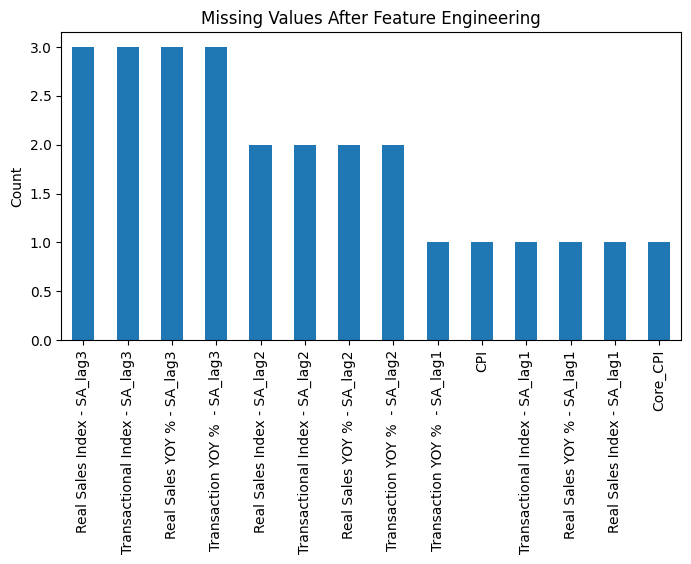

In [118]:
plt.figure(figsize=(8,4))

missing_report[missing_report>0].plot(kind="bar")

plt.title("Missing Values After Feature Engineering")
plt.ylabel("Count")

plt.show()

C:\Users\ericq\AppData\Local\Temp\ipykernel_8744\3792537005.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(12)


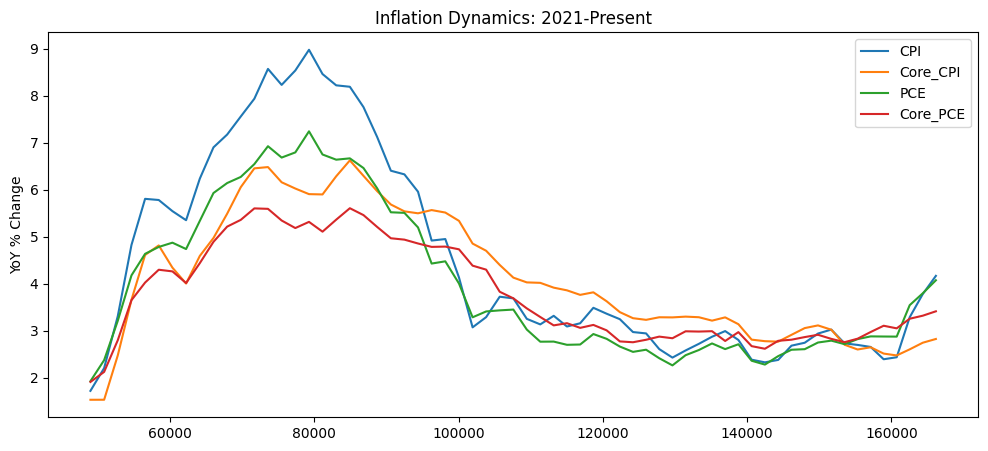

In [119]:
inflation_yoy = (
    data[
        ["CPI","Core_CPI","PCE","Core_PCE"]
    ]
    .pct_change(12)
    *100
)

plt.figure(figsize=(12,5))

for col in inflation_yoy:
    plt.plot(
        inflation_yoy.index,
        inflation_yoy[col],
        label=col
    )

plt.legend()
plt.title("Inflation Dynamics: 2021-Present")
plt.ylabel("YoY % Change")
plt.show()

C:\Users\ericq\AppData\Local\Temp\ipykernel_8744\348507885.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(12)


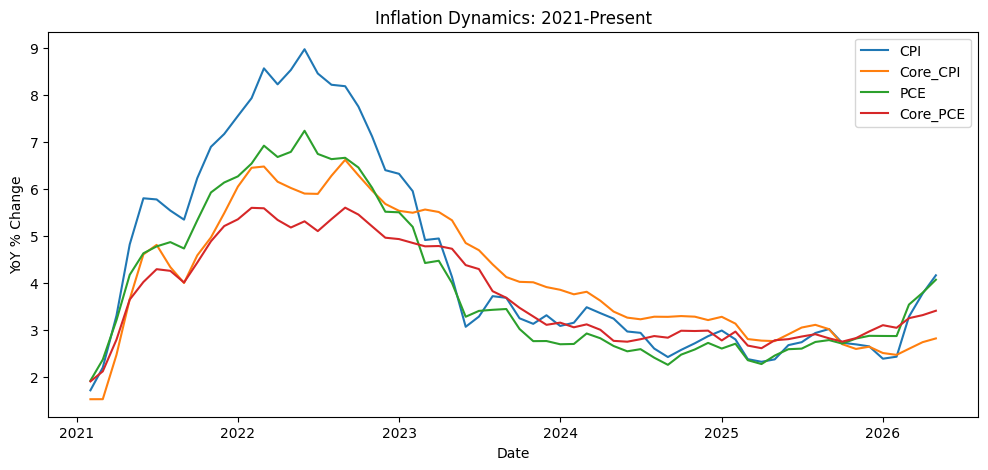

In [150]:
inflation_yoy = (
    data
    .set_index("Period")[
        ["CPI","Core_CPI","PCE","Core_PCE"]
    ]
    .pct_change(12)
    * 100
)

plt.figure(figsize=(12,5))

for col in inflation_yoy:
    plt.plot(
        inflation_yoy.index,
        inflation_yoy[col],
        label=col
    )

plt.legend()
plt.title("Inflation Dynamics: 2021-Present")
plt.ylabel("YoY % Change")
plt.xlabel("Date")

plt.savefig(
    "fsbi_inflation_dynamics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

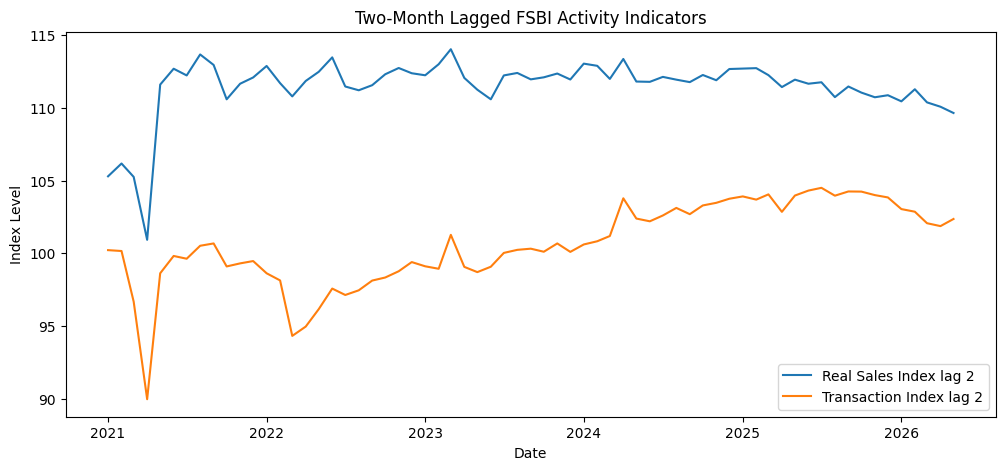

In [152]:
fsbi_plot = data[data["Period"] >= "2021-01-01"]

plt.figure(figsize=(12,5))

plt.plot(
    fsbi_plot["Period"],
    fsbi_plot["Real Sales Index - SA_lag2"],
    label="Real Sales Index lag 2"
)

plt.plot(
    fsbi_plot["Period"],
    fsbi_plot["Transactional Index - SA_lag2"],
    label="Transaction Index lag 2"
)

plt.legend()
plt.title("Two-Month Lagged FSBI Activity Indicators")
plt.xlabel("Date")
plt.ylabel("Index Level")

plt.savefig(
    "fsbi_lag.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
targets = [
    "CPI",
    "Core_CPI",
    "PCE",
    "Core_PCE"
]
corr_df = data[features + targets]

corr_df.dtypes

Real Sales Index - SA_lag1       float64
Real Sales Index - SA_lag2       float64
Real Sales Index - SA_lag3       float64
Transactional Index - SA_lag1    float64
Transactional Index - SA_lag2    float64
Transactional Index - SA_lag3    float64
Real Sales YOY % - SA_lag1       float64
Real Sales YOY % - SA_lag2       float64
Real Sales YOY % - SA_lag3       float64
Transaction YOY %  - SA_lag1     float64
Transaction YOY %  - SA_lag2     float64
Transaction YOY %  - SA_lag3     float64
fed_funds                        float64
treasury_10y                     float64
yield_spread_10y2y               float64
breakeven_5y                     float64
unemployment_rate                 object
avg_hourly_earnings               object
ppi_final_demand                  object
cpi_rent                          object
cpi_oer                           object
inflation_expectations_1y        float64
usd_index                        float64
CPI                              float64
Core_CPI        

In [ ]:
for col in corr_df.columns:
    if corr_df[col].dtype == "object":
        print(col, corr_df[col].unique()[:10])

unemployment_rate ['3.6' '3.5' '4.4' '14.8' '13.2' '11.0' '8.4' '7.8' '6.9' '6.7']
avg_hourly_earnings ['28.38' '28.43' '28.54' '28.73' '30.04' '29.72' '29.38' '29.49' '29.51'
 '29.54']
ppi_final_demand ['119.0' '119.2' '118.6' '118.0' '116.6' '117.2' '117.5' '118.4' '118.8'
 '119.4']
cpi_rent ['336.789' '337.825' '338.616' '339.519' '340.135' '340.811' '341.294'
 '342.444' '342.910' '343.615']
cpi_oer ['330.527' '331.522' '332.177' '332.864' '333.358' '334.052' '334.424'
 '335.763' '336.095' '336.965']


In [126]:
corr_df = data[features + targets].copy()

corr_df = corr_df.replace("-", np.nan)

corr_df = corr_df.apply(
    pd.to_numeric,
    errors="coerce"
)
corr_df.isna().sum().sort_values(ascending=False)

Transaction YOY %  - SA_lag3     3
Real Sales Index - SA_lag3       3
Transactional Index - SA_lag3    3
Real Sales YOY % - SA_lag3       3
Transaction YOY %  - SA_lag2     2
Transactional Index - SA_lag2    2
Real Sales YOY % - SA_lag2       2
Real Sales Index - SA_lag2       2
unemployment_rate                1
CPI                              1
Core_CPI                         1
Real Sales Index - SA_lag1       1
cpi_oer                          1
Transaction YOY %  - SA_lag1     1
Real Sales YOY % - SA_lag1       1
Transactional Index - SA_lag1    1
cpi_rent                         1
PCE                              0
usd_index                        0
inflation_expectations_1y        0
treasury_10y                     0
ppi_final_demand                 0
avg_hourly_earnings              0
breakeven_5y                     0
yield_spread_10y2y               0
fed_funds                        0
Core_PCE                         0
dtype: int64

In [135]:
features = [
    col for col in corr_df.columns
    if col not in targets + ["Period"]
]


corr = (
    corr_df[features + targets]
    .select_dtypes(include="number")
    .corr()
    .loc[features, targets]
)

corr

,CPI,Core_CPI,PCE,Core_PCE
Real Sales Index - SA_lag1,0.544961,0.507880,0.528339,0.502041
Real Sales Index - SA_lag2,0.565324,0.528002,0.548928,0.522067
Real Sales Index - SA_lag3,0.578126,0.539641,0.564151,0.536305
Transactional Index - SA_lag1,0.554507,0.570287,0.557085,0.568235
Transactional Index - SA_lag2,0.545214,0.564570,0.550958,0.564505
Transactional Index - SA_lag3,0.534799,0.554190,0.545815,0.559631
Real Sales YOY % - SA_lag1,-0.382313,-0.382192,-0.384062,-0.381251
Real Sales YOY % - SA_lag2,-0.369016,-0.369412,-0.372806,-0.371148
Real Sales YOY % - SA_lag3,-0.361324,-0.365477,-0.363252,-0.364161
Transaction YOY % - SA_lag1,0.144993,0.145260,0.137611,0.136984


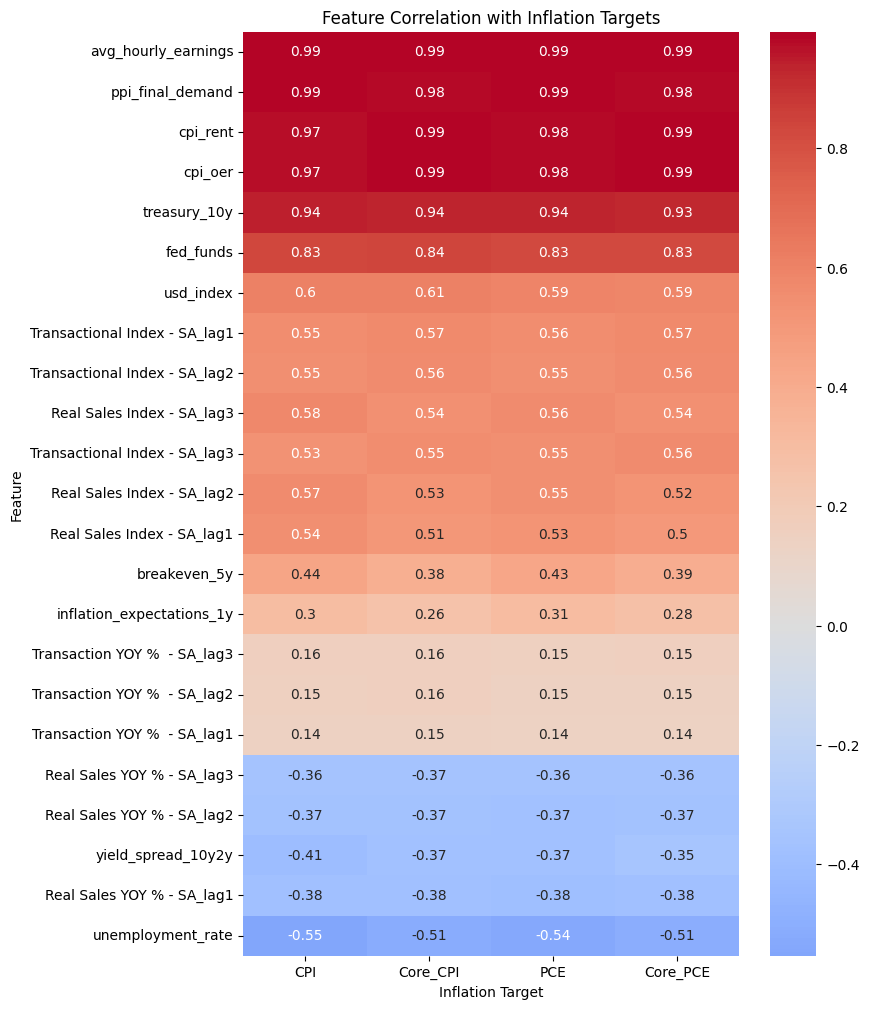

In [153]:
import seaborn as sns

corr_sorted = (
    corr
    .loc[
        corr.mean(axis=1)
        .sort_values(ascending=False)
        .index
    ]
)

plt.figure(figsize=(8,12))

sns.heatmap(
    corr_sorted,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation with Inflation Targets")
plt.xlabel("Inflation Target")
plt.ylabel("Feature")
plt.savefig(
    "corr_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [141]:
lags = {}

for lag in [1,2,3]:
    lags[f"Sales lag {lag}"] = (
        data[
            f"Real Sales Index - SA_lag{lag}"
        ]
        .corr(data["CPI"])
    )

pd.Series(lags)

Sales lag 1    0.544961
Sales lag 2    0.565324
Sales lag 3    0.578126
dtype: float64

In [145]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data[
    [
        c for c in data.columns
        if c not in targets + ["Period"]
    ]
].dropna()

X = X.replace("-", np.nan)
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)
X = X.dropna()

vif = pd.DataFrame()

vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    "VIF",
    ascending=False
)

,Feature,VIF
20,cpi_oer,2.423565e+06
19,cpi_rent,1.782251e+06
17,avg_hourly_earnings,4.330334e+05
1,Real Sales Index - SA_lag2,7.669456e+04
4,Transactional Index - SA_lag2,7.157740e+04
18,ppi_final_demand,6.834838e+04
2,Real Sales Index - SA_lag3,5.805113e+04
0,Real Sales Index - SA_lag1,5.630337e+04
5,Transactional Index - SA_lag3,4.637829e+04
3,Transactional Index - SA_lag1,3.641287e+04


In [147]:
X_vif = X.copy()
X_vif = X_vif.diff().dropna()
vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif.sort_values(
    "VIF",
    ascending=False
)

,Feature,VIF
20,cpi_oer,83.818682
19,cpi_rent,71.827975
6,Real Sales YOY % - SA_lag1,57.921040
10,Transaction YOY % - SA_lag2,54.833063
11,Transaction YOY % - SA_lag3,52.786642
8,Real Sales YOY % - SA_lag3,48.734224
9,Transaction YOY % - SA_lag1,48.126528
5,Transactional Index - SA_lag3,47.613892
7,Real Sales YOY % - SA_lag2,46.727553
4,Transactional Index - SA_lag2,43.526858


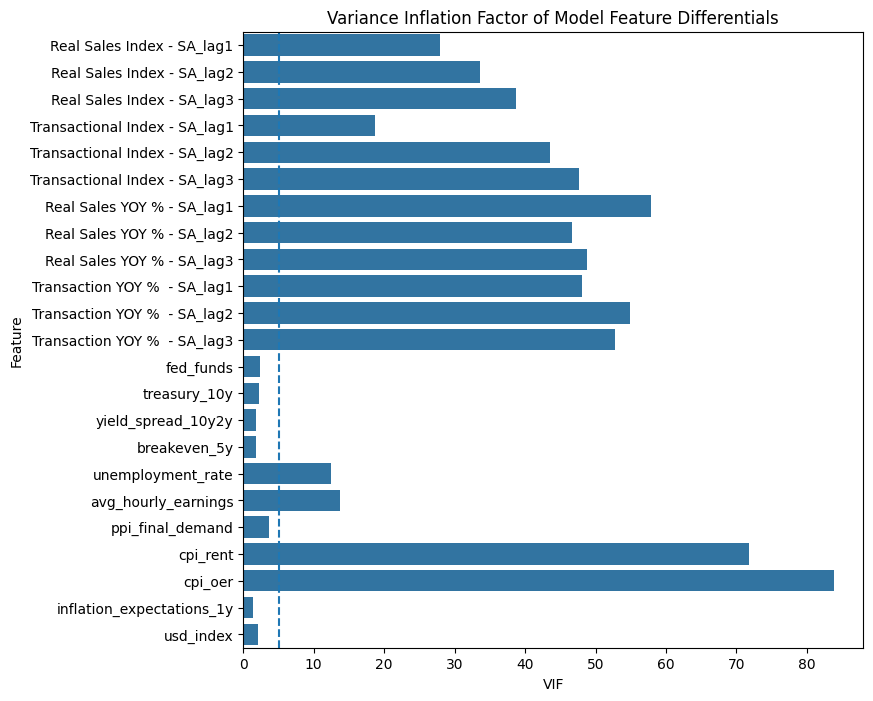

In [154]:
plt.figure(figsize=(8,8))

sns.barplot(
    data=vif,
    y="Feature",
    x="VIF"
)

plt.axvline(
    5,
    linestyle="--"
)

plt.title("Variance Inflation Factor of Model Feature Differentials")
plt.xlabel("VIF")
plt.savefig(
    "vif_diffs.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [113]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Period,142028,2023-02-17 11:50:36.077393152,2020-01-01 00:00:00,2021-07-01 00:00:00,2023-02-01 00:00:00,2024-10-01 00:00:00,2026-05-01 00:00:00,NaN
Real Sales Index - SA,142028.0,116.317628,17.28,101.83,113.21,125.02,329.56,27.829394
Transactional Index - SA,142028.0,117.29629,7.78,96.33,109.65,128.64,357.44,38.542904
Real Sales MOM % - SA,140498.0,0.435559,-73.59,-1.51,-0.03,1.81,330.0,7.834257
Real Sales YOY % - SA,139228.0,4.391871,-80.77,-4.37,0.955,9.39,742.5,20.416852
Transaction MOM % - SA,140499.0,0.622022,-83.1,-1.43,0.15,2.14,722.43,9.481169
Transaction YOY % - SA,139231.0,5.844032,-91.96,-4.09,2.62,11.63,1410.65,25.870245
Real Sales Index - NSA,142028.0,117.494477,15.06,96.59,111.96,130.8025,349.27,35.036474
Transactional Index - NSA,142028.0,118.859204,6.02,92.07,109.04,133.94,479.33,49.096501
Real Sales MOM % - NSA,140493.0,1.240472,-74.84,-5.97,-0.04,6.85,674.35,14.632788
